# Exploratory Data Analysis and Predictive Modeling of District Delivery Rate  
### Project  
**Name:** Sarthak Rana

In [1]:
#Dataset path :
path = "final_capstone_dataset.csv"

In [8]:
#STEP 1: Import & Basic Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv(path)

# Basic check
df.shape

/tmp/ipython-input-1480544600.py:8: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


(163014, 28)

In [10]:
# sample first 5 rows
df.head()

,circlename,regionname,divisionname,officetype,delivery,district,State,latitude,longitude,Head_PO,...,division_office_count,district_delivery_rate,circle_delivery_rate,region_delivery_rate,pincode_zone,pincode_subzone,officetype_encoded,district_bo_ratio,district_po_ratio,district_ho_ratio
0,Telangana Circle,Hyderabad Region,Adilabad Division,BO,1,KUMURAM BHEEM ASIFABAD,telangana,19.363869,79.537666,36,...,586,0.97037,0.959252,0.970372,5,50,0,0.925926,0.074074,0.0
1,Telangana Circle,Hyderabad Region,Adilabad Division,BO,1,KUMURAM BHEEM ASIFABAD,telangana,19.47649,79.583923,36,...,586,0.97037,0.959252,0.970372,5,50,0,0.925926,0.074074,0.0
2,Telangana Circle,Hyderabad Region,Adilabad Division,BO,1,KUMURAM BHEEM ASIFABAD,telangana,NaN,NaN,36,...,586,0.97037,0.959252,0.970372,5,50,0,0.925926,0.074074,0.0
3,Telangana Circle,Hyderabad Region,Adilabad Division,BO,1,KUMURAM BHEEM ASIFABAD,telangana,19.328575,79.476013,36,...,586,0.97037,0.959252,0.970372,5,50,0,0.925926,0.074074,0.0
4,Telangana Circle,Hyderabad Region,Adilabad Division,BO,1,KUMURAM BHEEM ASIFABAD,telangana,19.377804,79.616521,36,...,586,0.97037,0.959252,0.970372,5,50,0,0.925926,0.074074,0.0


In [7]:
# data types and count
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136936 entries, 0 to 136935
Data columns (total 28 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   circlename              136936 non-null  object 
 1   regionname              136928 non-null  object 
 2   divisionname            136936 non-null  object 
 3   officetype              136936 non-null  object 
 4   delivery                136936 non-null  int64  
 5   district                136936 non-null  object 
 6   State                   136936 non-null  object 
 7   latitude                126877 non-null  object 
 8   longitude               126882 non-null  object 
 9   Head_PO                 136936 non-null  int64  
 10  Sub_PO                  136936 non-null  int64  
 11  Branch_PO               136936 non-null  int64  
 12  Total_PO                136936 non-null  int64  
 13  Head_PO_Ratio           136936 non-null  float64
 14  Branch_PO_Ratio     

In [6]:
# five point summary
df.describe()

,delivery,Head_PO,Sub_PO,Branch_PO,Total_PO,Head_PO_Ratio,Branch_PO_Ratio,district_office_count,circle_office_count,region_office_count,division_office_count,district_delivery_rate,circle_delivery_rate,region_delivery_rate,pincode_zone,pincode_subzone,officetype_encoded,district_bo_ratio,district_po_ratio,district_ho_ratio
count,136936.000000,136936.000000,136936.000000,136936.000000,136936.000000,136936.000000,136936.000000,136936.000000,136936.000000,136928.000000,136936.000000,136936.000000,136936.000000,136928.000000,136936.000000,136936.000000,136936.000000,136936.000000,136936.000000,136936.000000
mean,0.955417,45.933443,1408.760209,7639.636129,9094.329782,0.005159,0.837821,328.294992,9727.036900,8462.101338,435.534155,0.954161,0.954008,0.953792,4.708236,51.246100,0.150596,0.848412,0.146712,0.004875
std,0.206387,22.378812,713.551501,3639.467028,4284.187571,0.001739,0.052619,166.987375,4129.096645,10744.796773,190.206491,0.067490,0.041752,0.031469,2.042106,20.529656,0.370730,0.100147,0.096937,0.004194
min,0.000000,1.000000,22.000000,9.000000,51.000000,0.001425,0.176471,1.000000,2.000000,1.000000,1.000000,0.028571,0.308530,0.393013,1.000000,11.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,32.000000,985.000000,4974.000000,5835.000000,0.004077,0.822829,201.000000,6258.000000,2813.000000,311.000000,0.947368,0.945960,0.951460,3.000000,36.000000,0.000000,0.825269,0.095794,0.002817
50%,1.000000,45.000000,1296.000000,7951.000000,9037.000000,0.004682,0.850997,300.000000,9658.000000,3547.000000,401.000000,0.972028,0.958271,0.954511,5.000000,50.000000,0.000000,0.870588,0.125000,0.004454
75%,1.000000,59.000000,2053.000000,9240.000000,12035.000000,0.005716,0.855935,426.000000,11824.000000,4886.000000,515.000000,0.985915,0.971086,0.971525,7.000000,71.000000,0.000000,0.900901,0.168539,0.006144
max,1.000000,93.000000,2702.000000,15111.000000,17662.000000,0.021661,0.920228,819.000000,17971.000000,30552.000000,1265.000000,1.000000,1.000000,1.000000,9.000000,90.000000,2.000000,1.000000,1.000000,0.071429


In [12]:
# missing values in all variables
df.isnull().sum()

,0
circlename,0
regionname,9
divisionname,0
officetype,0
delivery,0
district,0
State,0
latitude,11776
longitude,11771
Head_PO,0


In [13]:
# total missing values in entire dataset
df.isnull().sum().sum()

np.int64(23574)

**Dataset contains 163014 rows and 28 columns with 11776 in latitude and 11771 in longitude missing values.**

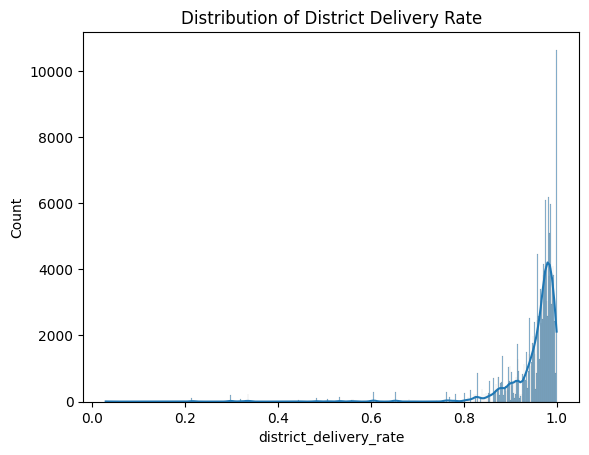

In [15]:
#STEP 2: UNIVARIATE ANALYSIS
#2.1 Target Variable Distribution
plt.figure()
sns.histplot(df['district_delivery_rate'], kde=True)
plt.title("Distribution of District Delivery Rate")
plt.show()

* It is not normally distributed.
* It is left-skewed (negatively skewed).

  Because:

  Tail is on the left

  Majority of data is on the right

* There are extreme low delivery rate values (close to 0–0.4) compared to the majority clustered near 0.9–1.0.
* The target variable is not normally distributed and shows strong negative (left) skewness, with most delivery rates concentrated near 1.0. A few low values create a long left tail, indicating the presence of potential outliers.

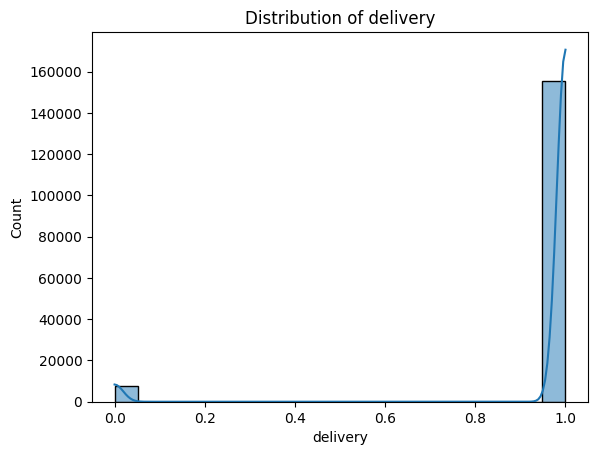

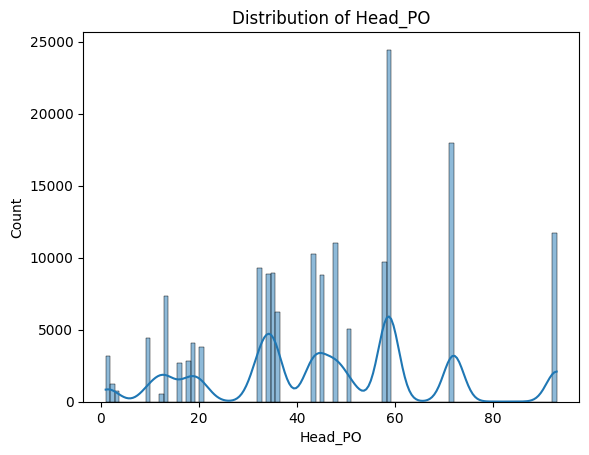

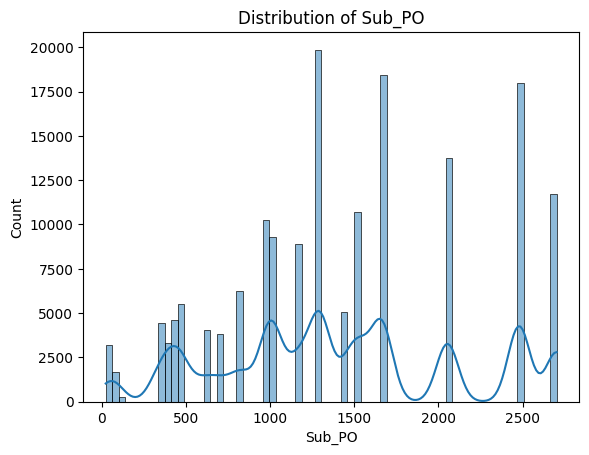

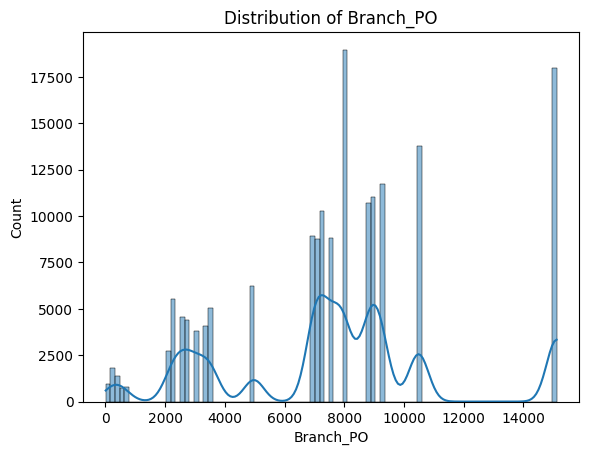

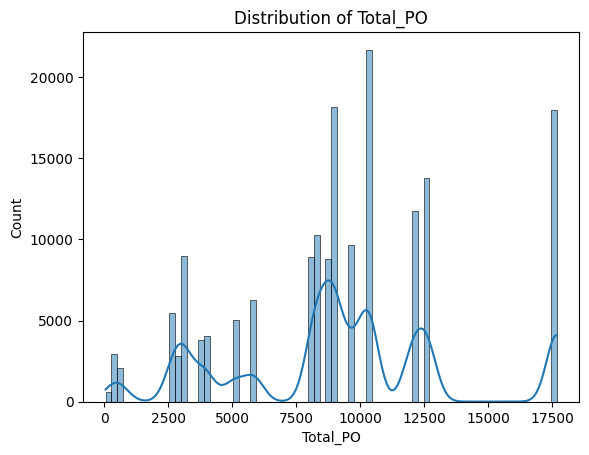

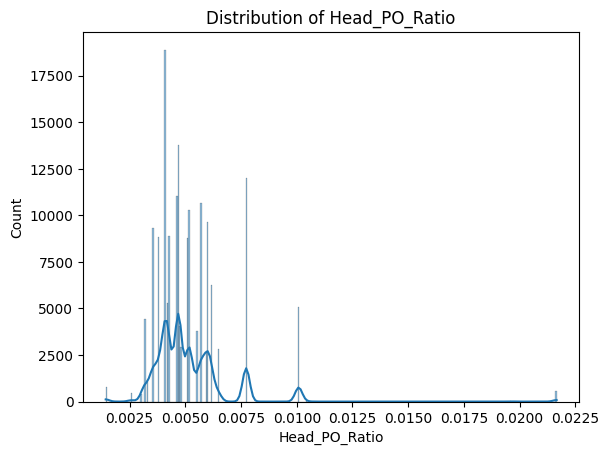

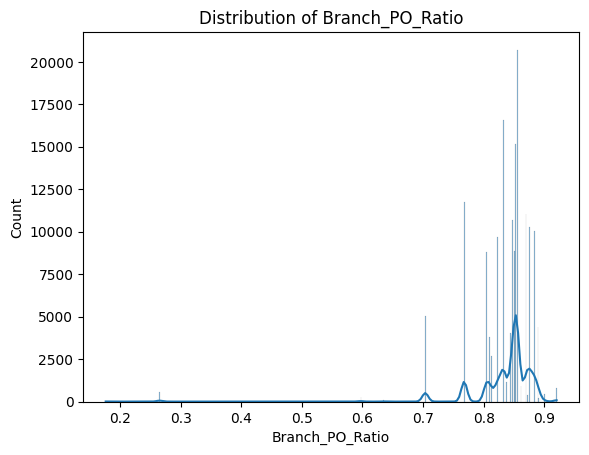

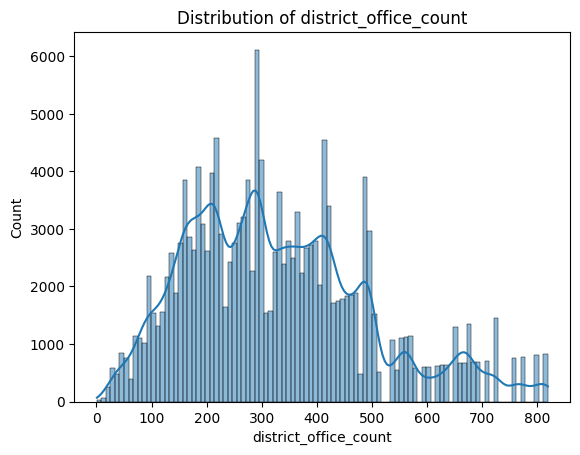

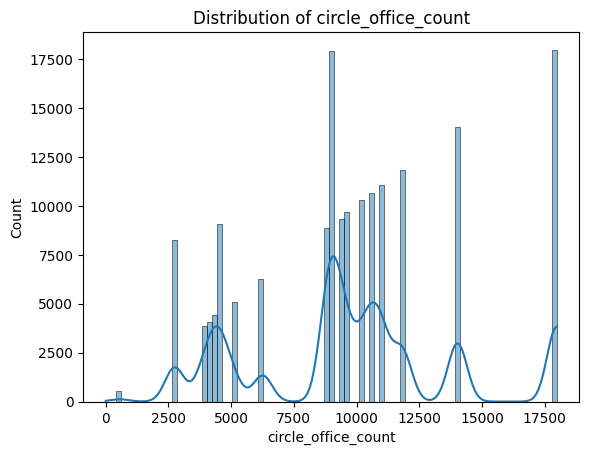

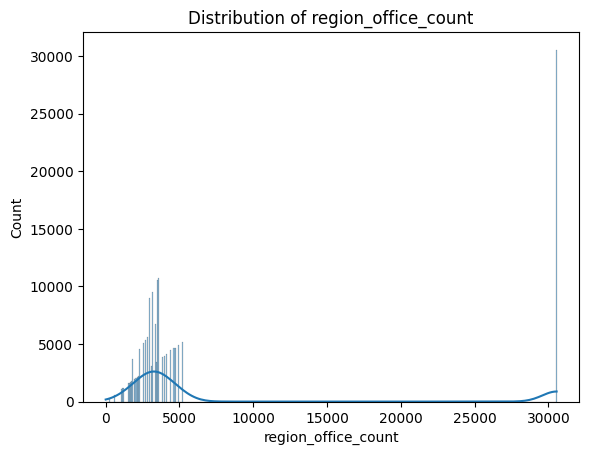

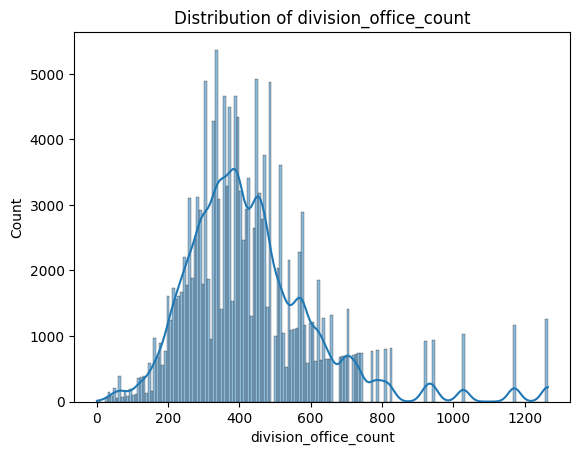

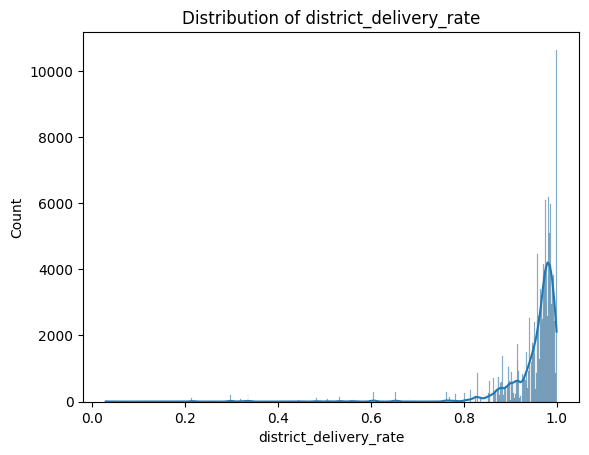

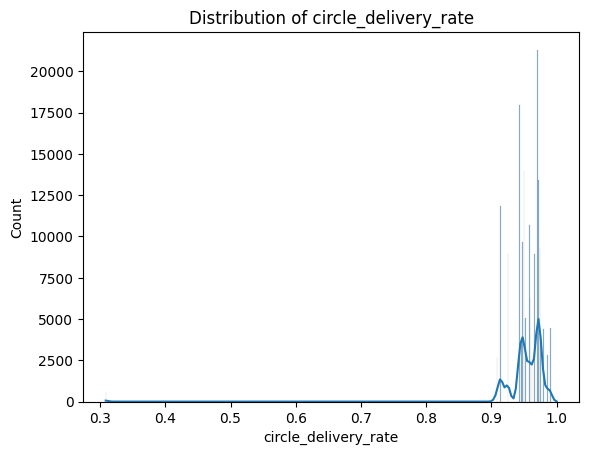

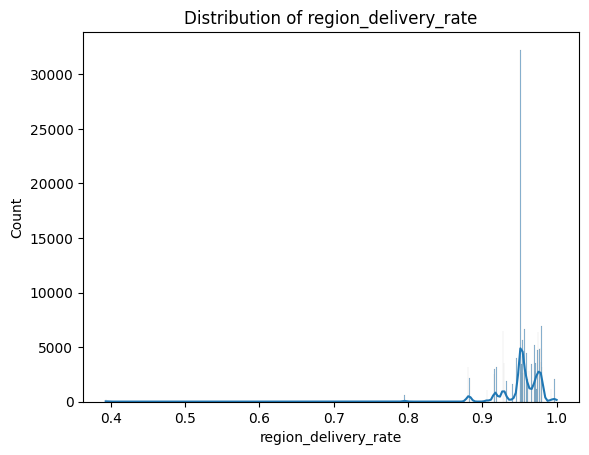

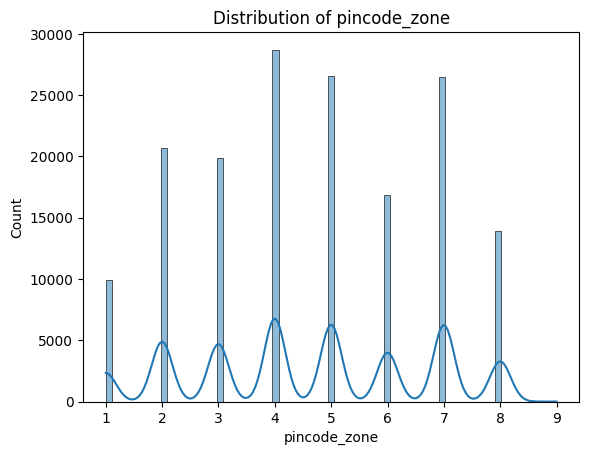

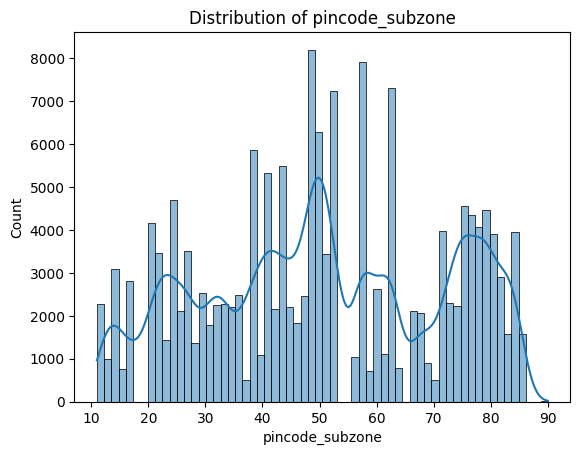

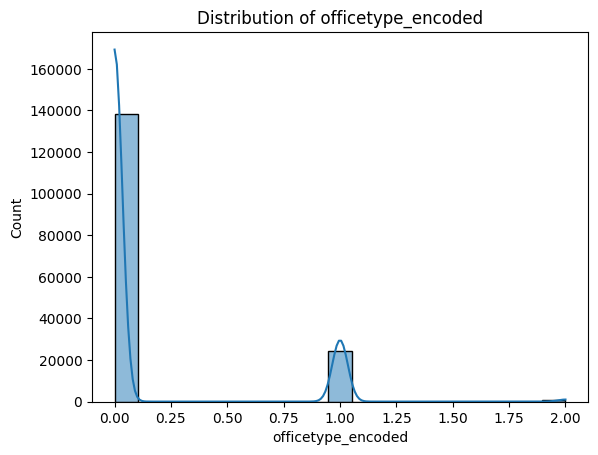

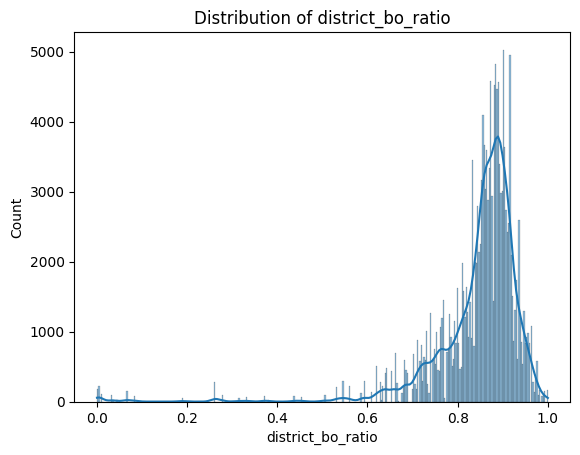

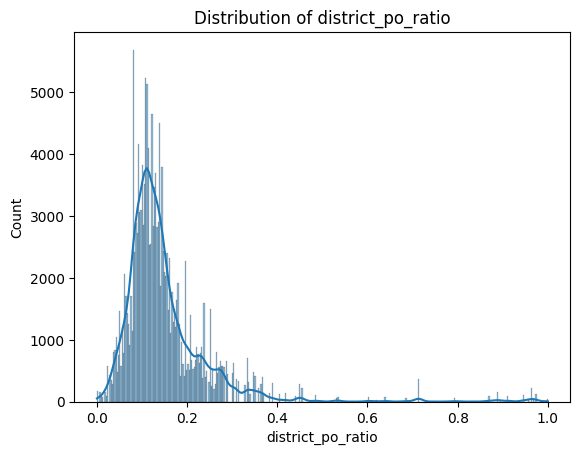

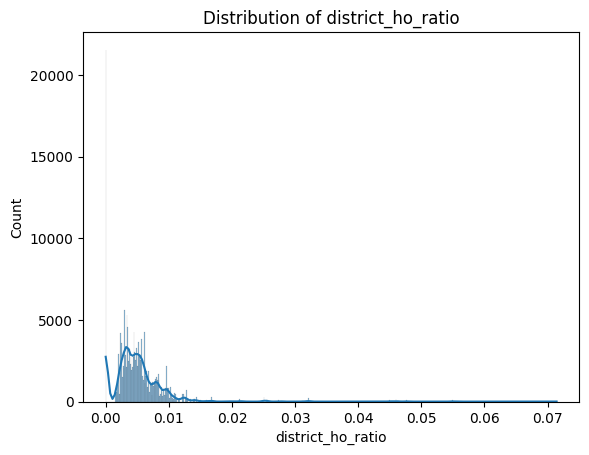

In [16]:
#2.2 Numerical Features Distribution
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

**📌 Univariate Analysis Summary**

* The univariate analysis reveals that most numerical features exhibit non-normal distributions with noticeable skewness and outliers.
* Several office count variables such as Branch_PO, Total_PO, Sub_PO, division_office_count, and district_office_count show strong right skewness, indicating the presence of districts with significantly higher office counts compared to the majority.
* Delivery-related variables including district_delivery_rate, circle_delivery_rate, and region_delivery_rate are strongly left-skewed, with most values concentrated near 1.0.
* This suggests consistently high delivery performance across administrative levels, with only a few low-performing outliers.
* Ratio-based features such as district_bo_ratio and Branch_PO_Ratio are primarily left-skewed, indicating high proportion concentration, while district_po_ratio and district_ho_ratio show right skewness with small clusters of higher values.
* Overall, the dataset contains multiple skewed distributions and upper-range outliers, which may require scaling or transformation before modeling.

**Due to skewness and presence of outliers, feature scaling and potential transformation (e.g., log transformation for highly skewed count variables) may improve model performance.**

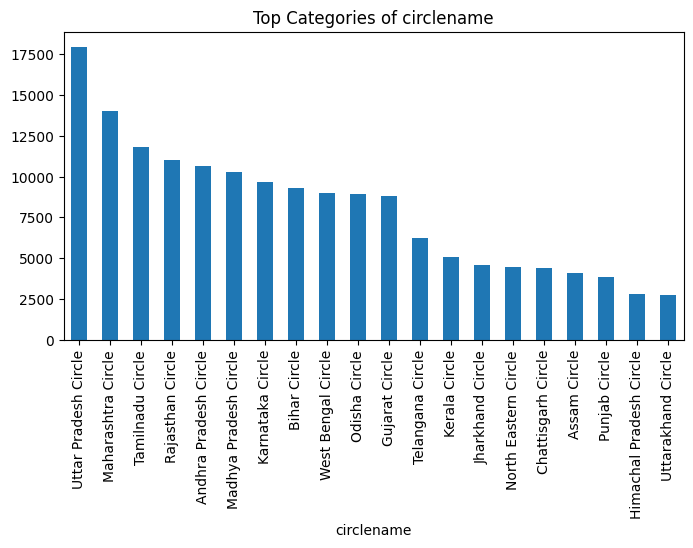

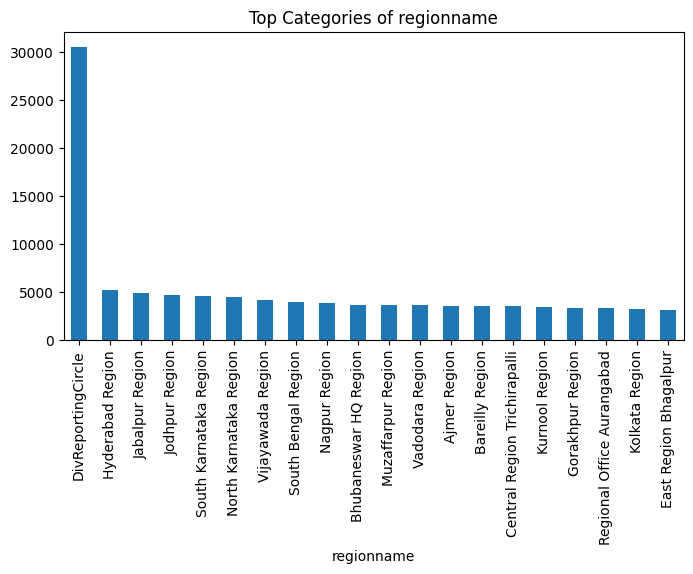

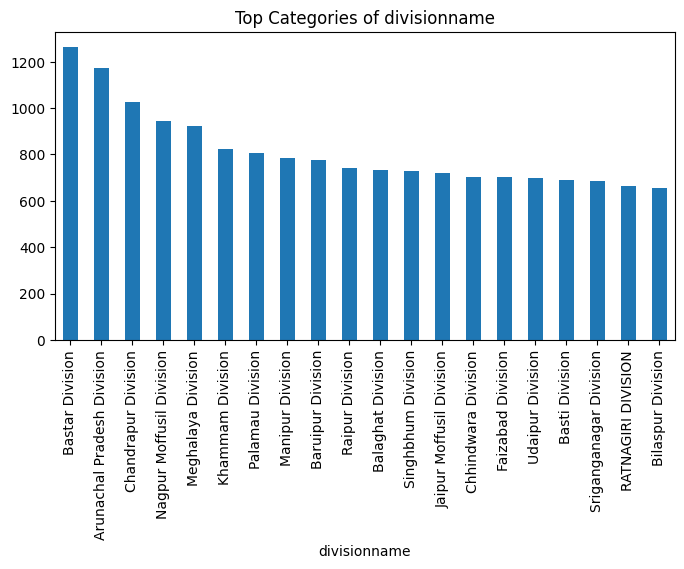

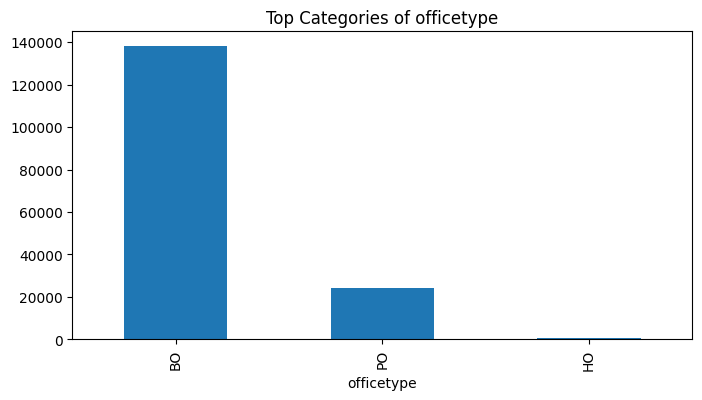

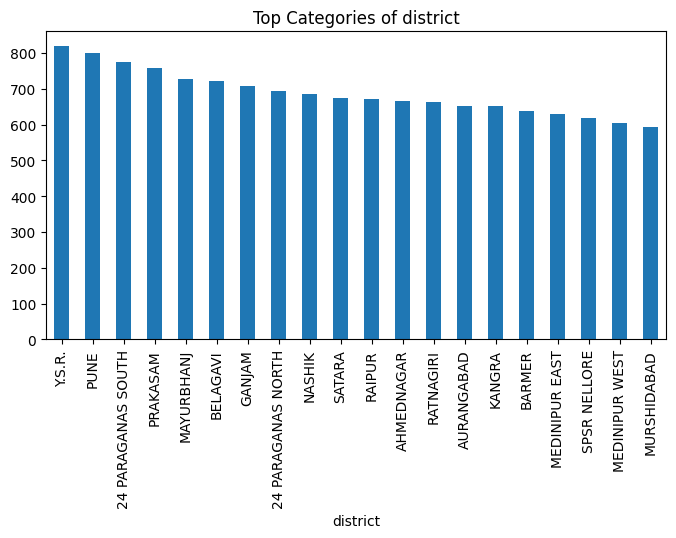

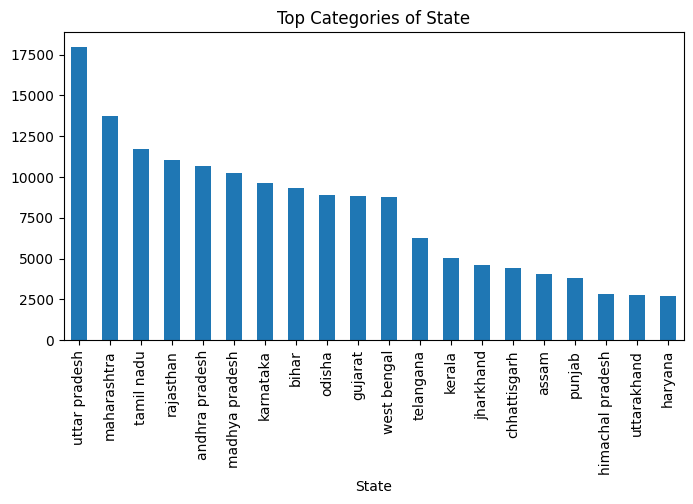

In [18]:
#2.3 Categorical Feature Distribution
cat_cols = df.select_dtypes(include=['object']).columns

# Remove unnecessary high-cardinality columns if present
exclude_cols = ['latitude', 'longitude']
cat_cols = [col for col in cat_cols if col not in exclude_cols]

for col in cat_cols:
    plt.figure(figsize=(8,4))
    df[col].value_counts().head(20).plot(kind='bar')  # only top 20
    plt.title(f"Top Categories of {col}")
    plt.show()

**📌 Categorical Feature Analysis Summary**
* The categorical feature analysis indicates noticeable imbalance across multiple administrative levels.
* The officetype variable is highly imbalanced, with Branch Offices (BO) contributing the majority of records compared to PO and HO.
* At the regional level, certain regions such as DivReportingCircle dominate the dataset, reflecting uneven data representation.
* Similarly, Uttar Pradesh leads in both state and circle-level distributions.
* These imbalances may influence model learning and should be considered during encoding and model evaluation to avoid bias toward dominant categories.

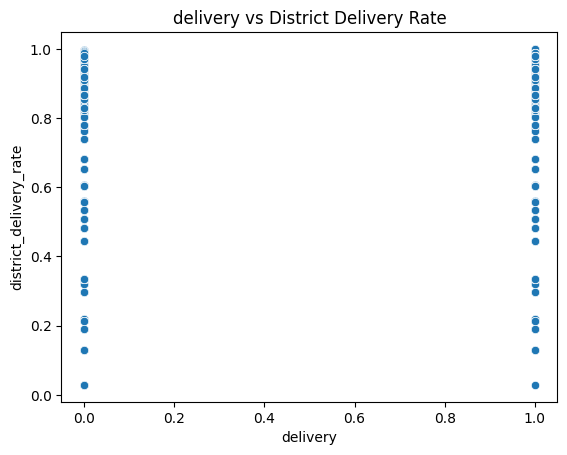

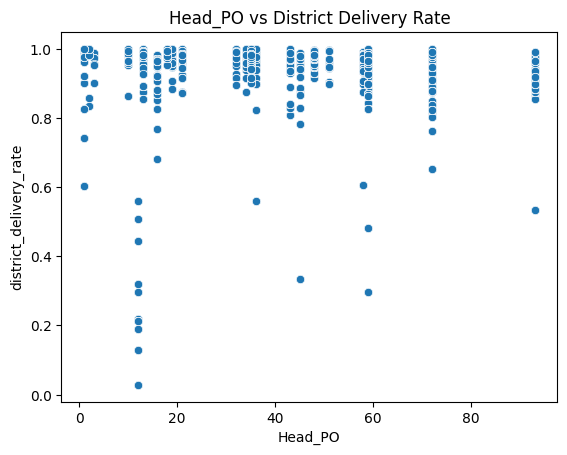

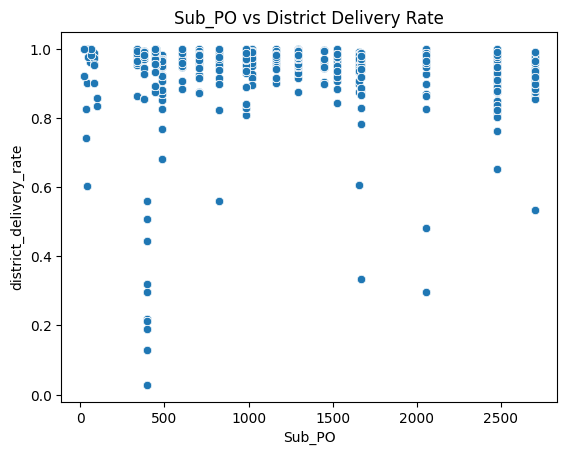

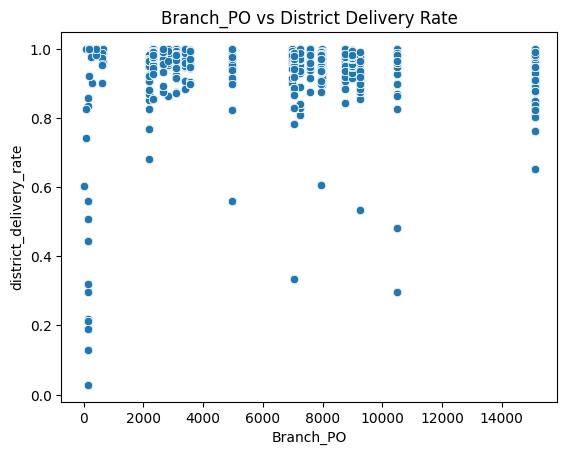

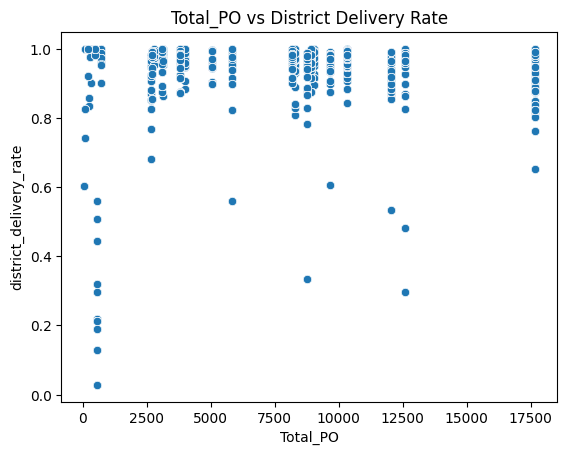

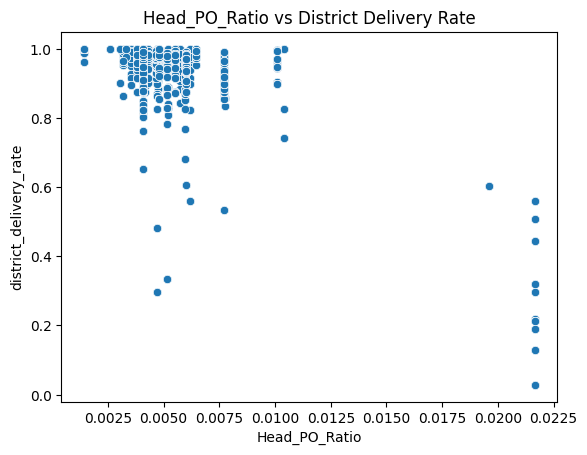

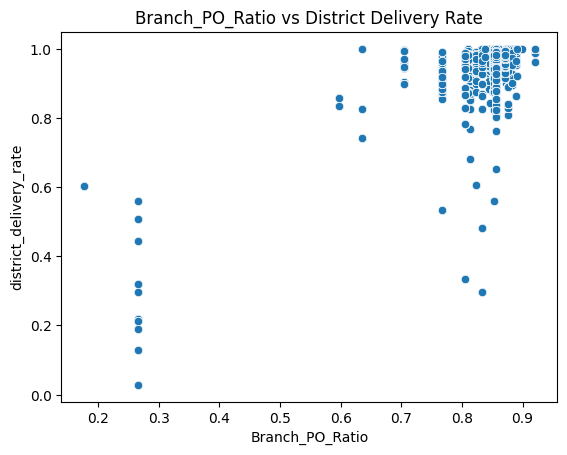

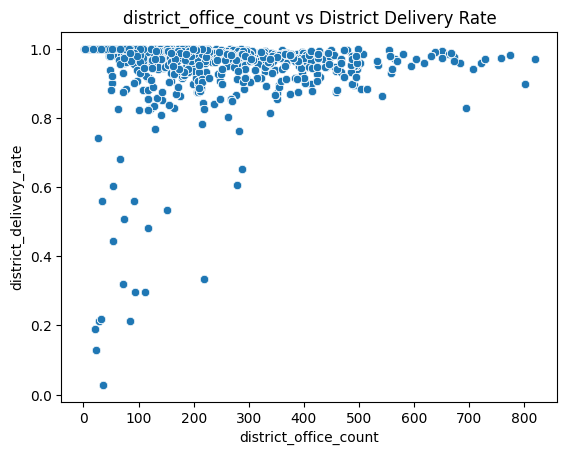

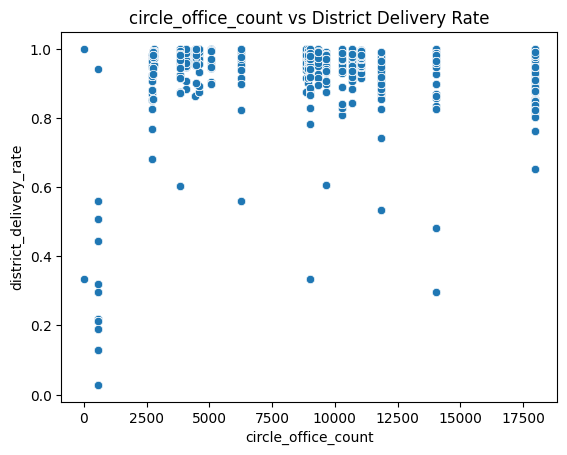

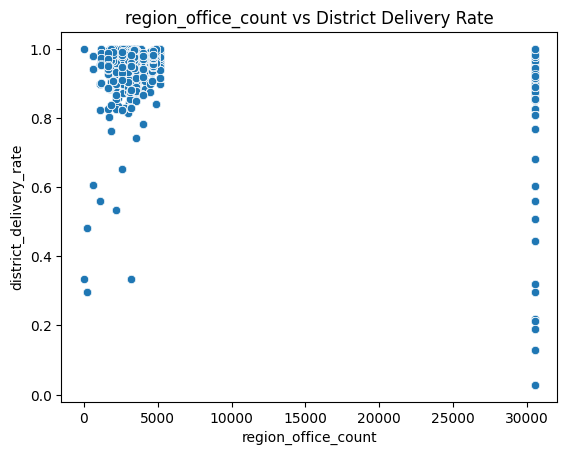

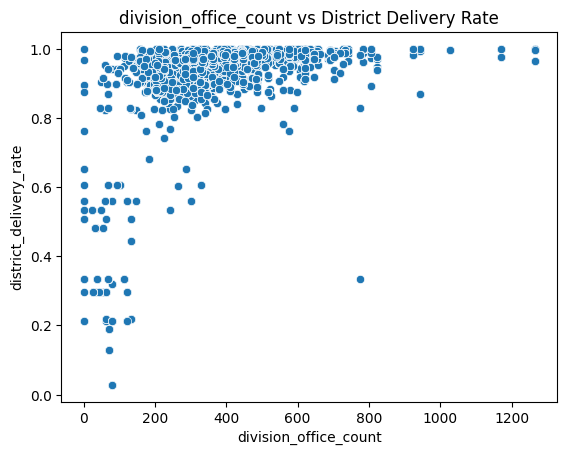

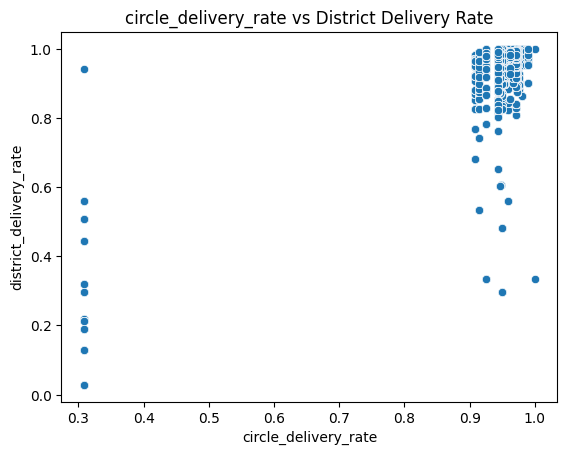

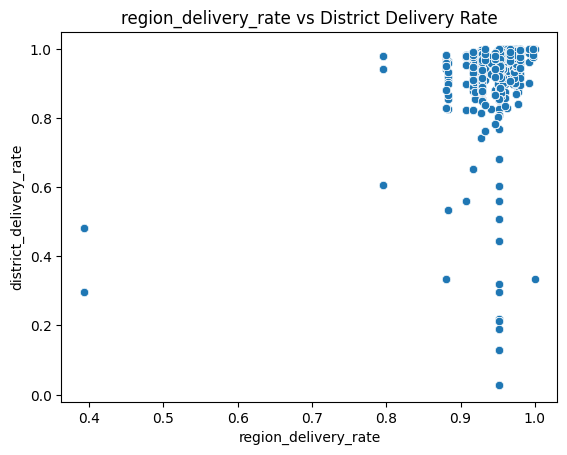

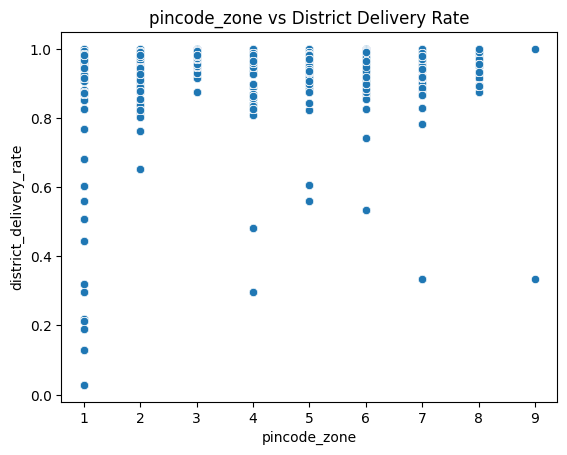

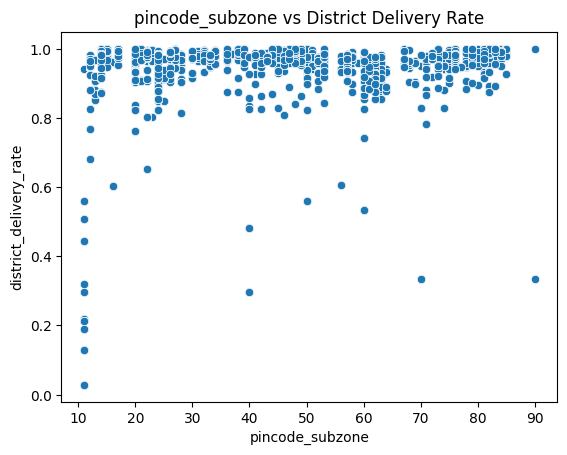

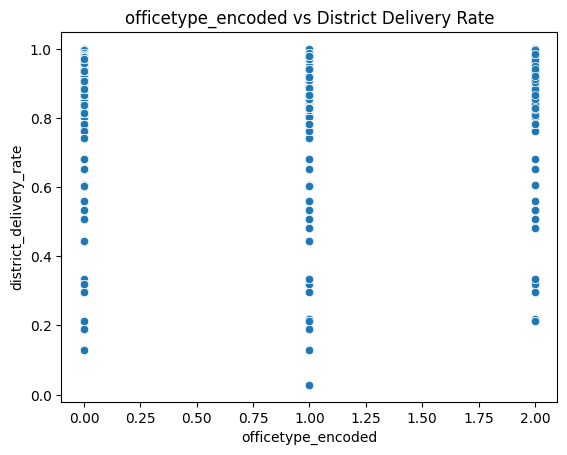

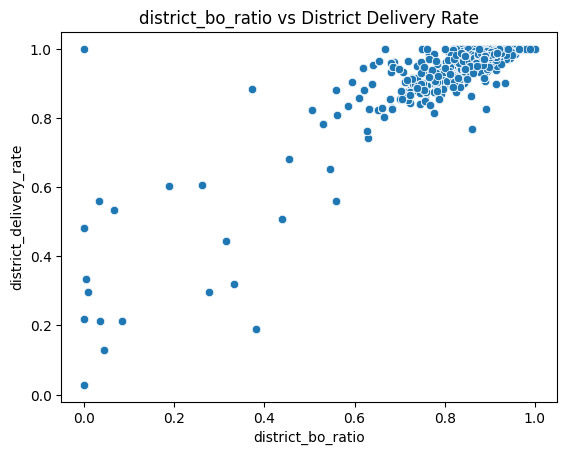

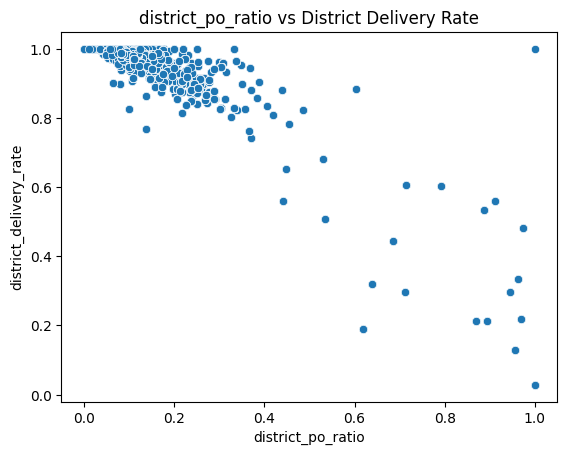

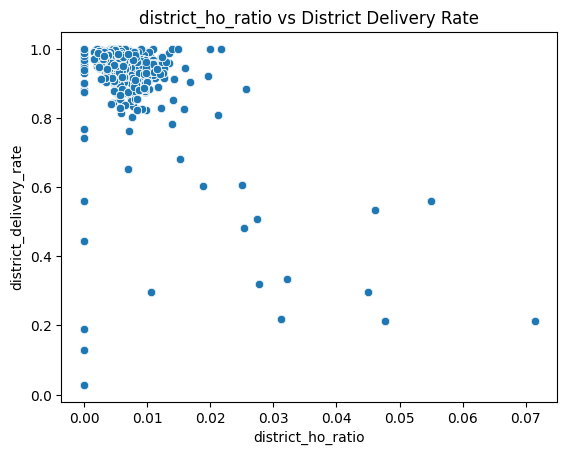

In [21]:
#STEP 3: BIVARIATE ANALYSIS
#3.1 Numerical Features vs Target (Scatter Plot)
for col in num_cols:
    if col != 'district_delivery_rate':
        plt.figure()
        sns.scatterplot(x=df[col], y=df['district_delivery_rate'])
        plt.title(f"{col} vs District Delivery Rate")
        plt.show()

**🔎 Bivariate Analysis Summary**

* The bivariate analysis reveals strong relationships between delivery performance and infrastructure-related variables. District delivery rate shows a strong positive correlation with circle and region delivery rates, indicating hierarchical performance consistency across administrative levels.
* Ratio-based variables demonstrate meaningful trends. District BO ratio exhibits a positive relationship with delivery performance, while district PO ratio shows a negative association, suggesting that office composition may influence service efficiency.
* Infrastructure variables such as Total_PO, Branch_PO, and district office counts display moderate positive relationships with delivery rate, indicating that increased postal infrastructure may support improved delivery outcomes.
* Some features such as pincode zone and encoded office type show weak or no clear relationship with the target variable.
* Overall, the analysis identifies key predictive variables for modeling while highlighting less influential features.

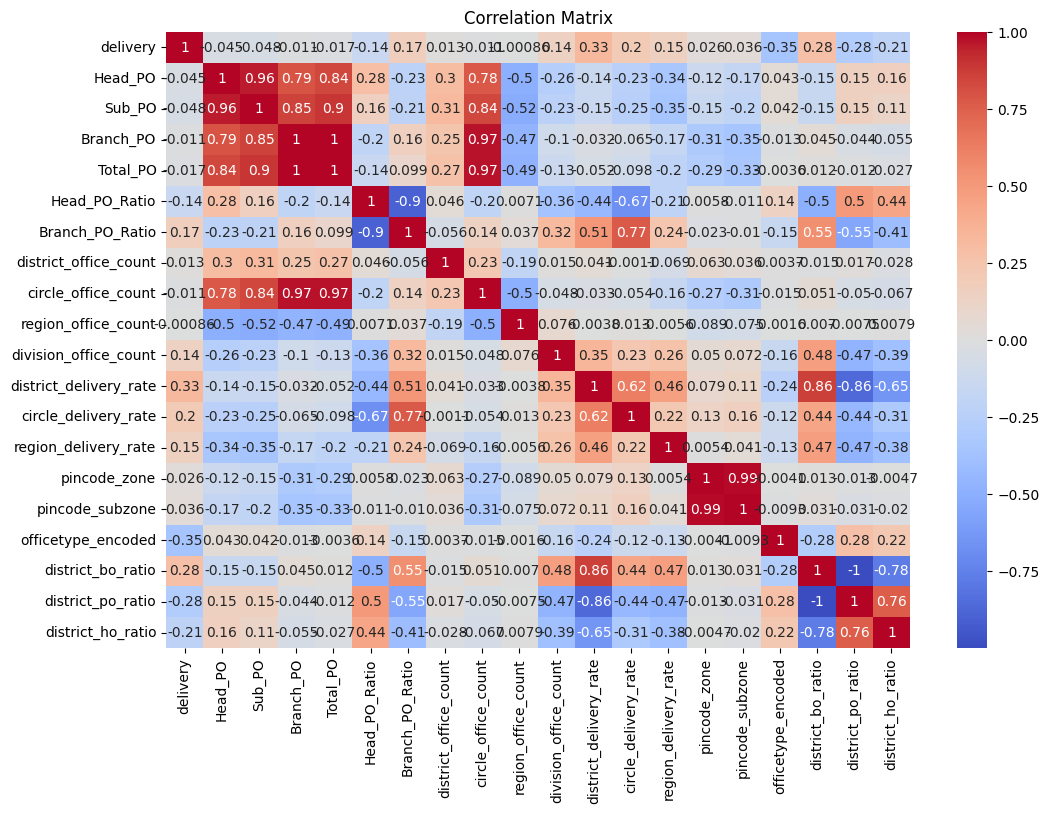

district_delivery_rate    1.000000
district_bo_ratio         0.861877
circle_delivery_rate      0.617530
Branch_PO_Ratio           0.511362
region_delivery_rate      0.463908
division_office_count     0.346908
delivery                  0.325846
pincode_subzone           0.107559
pincode_zone              0.079120
district_office_count     0.041051
region_office_count      -0.003829
Branch_PO                -0.031928
circle_office_count      -0.032942
Total_PO                 -0.052162
Head_PO                  -0.136247
Sub_PO                   -0.146386
officetype_encoded       -0.239826
Head_PO_Ratio            -0.437320
district_ho_ratio        -0.647565
district_po_ratio        -0.862571
Name: district_delivery_rate, dtype: float64


In [23]:
#3.2 Correlation with Target
# Select only numeric columns
num_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr_matrix = num_df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Correlation with target
corr_with_target = corr_matrix['district_delivery_rate'].sort_values(ascending=False)
print(corr_with_target)

🔎 Correlation Analysis Summary

* The correlation analysis reveals that district delivery rate is strongly influenced by infrastructure composition and hierarchical performance metrics.
* The strongest positive correlation is observed with district_bo_ratio (0.86), indicating that higher Branch Office proportion significantly improves delivery performance. Similarly, circle_delivery_rate (0.62) and region_delivery_rate (0.46) show strong positive relationships, reflecting performance consistency across administrative levels.
* Conversely, district_po_ratio (-0.86) and district_ho_ratio (-0.65) exhibit strong negative correlations, suggesting that higher concentration of PO and HO offices may reduce delivery efficiency at the district level.
* Infrastructure counts such as Total_PO and Branch_PO show weak correlation, indicating that office composition ratio is more influential than absolute counts.
* The heatmap also reveals multicollinearity among office count variables and pincode-related features, suggesting the need for careful feature selection before modeling.

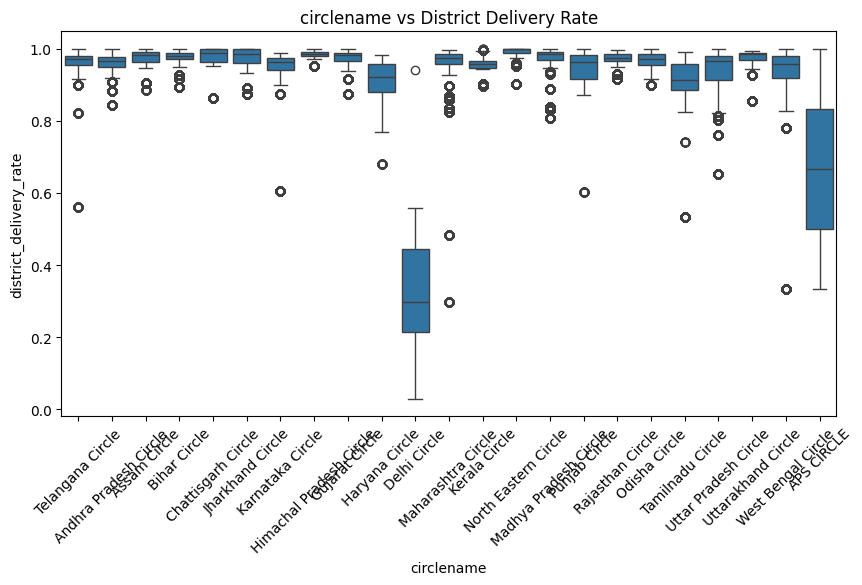

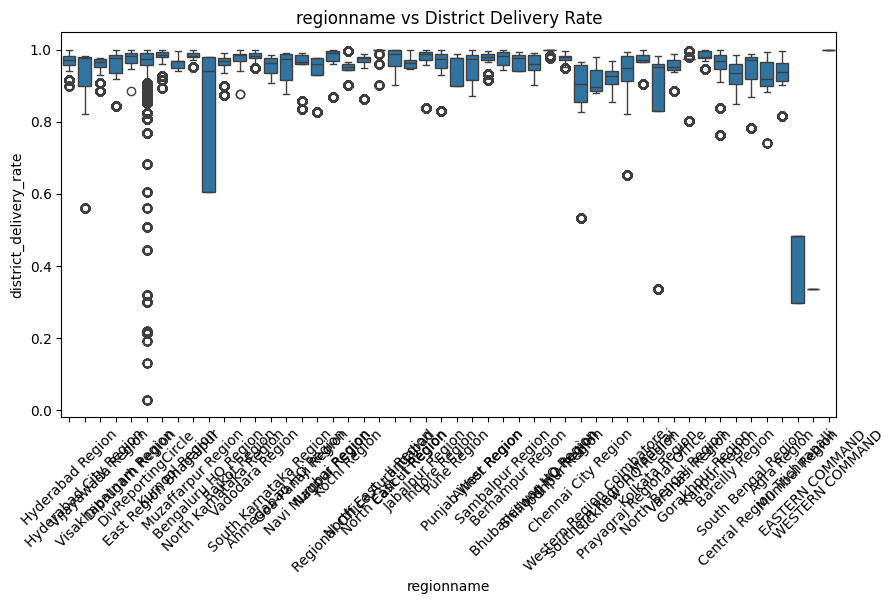

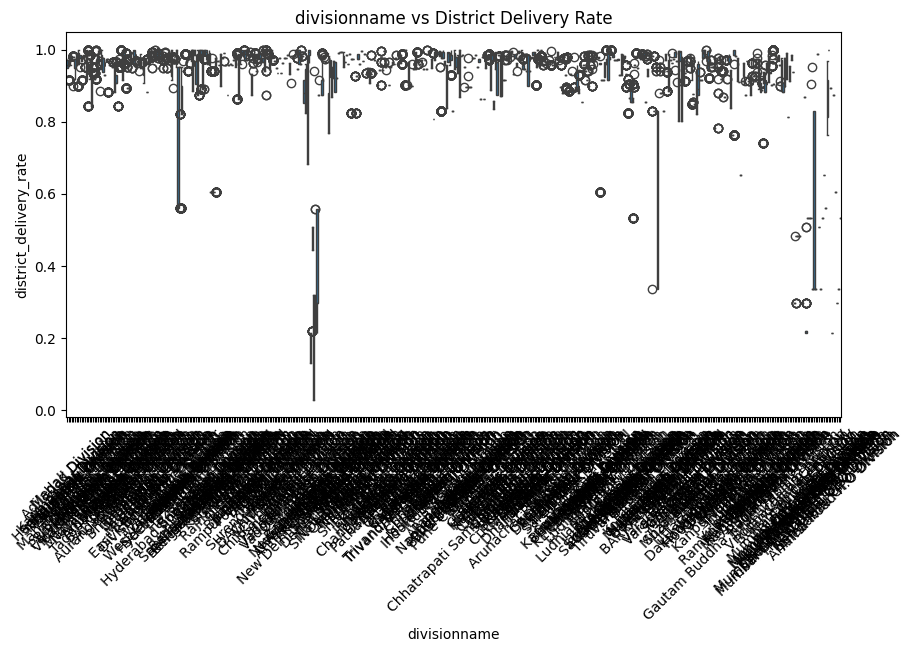

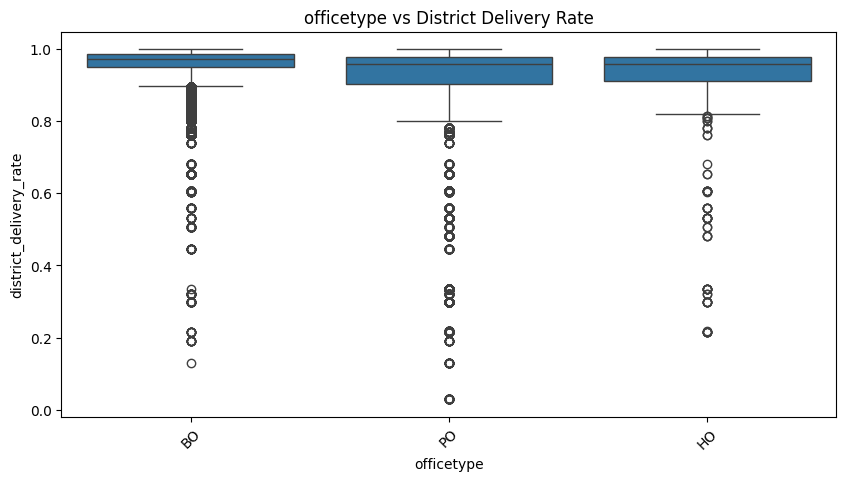

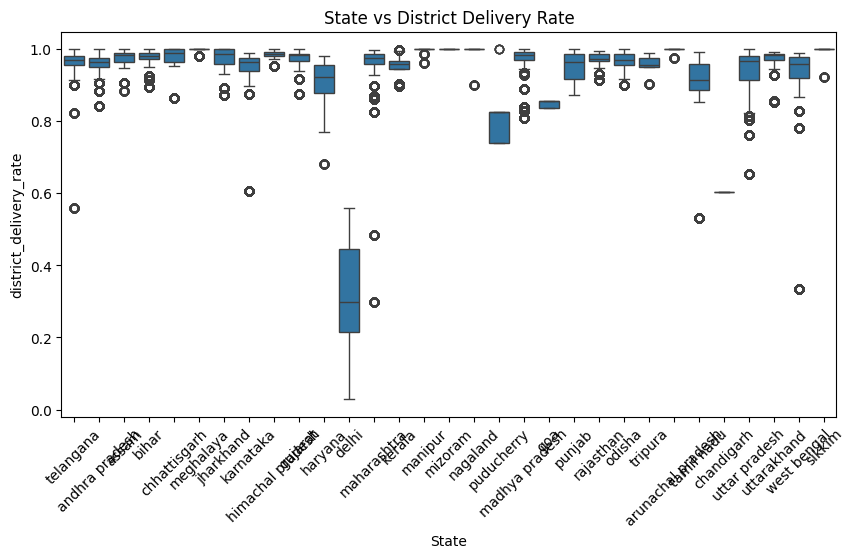

In [26]:
#3.3 Categorical vs Target (Boxplot)
cat_cols = df.select_dtypes(include=['object']).columns

# Columns to exclude
exclude_cols = ['latitude', 'longitude', 'district']

cat_cols = [col for col in cat_cols if col not in exclude_cols]

for col in cat_cols:
    plt.figure(figsize=(10,5))
    sns.boxplot(x=df[col], y=df['district_delivery_rate'])
    plt.xticks(rotation=45)
    plt.title(f"{col} vs District Delivery Rate")
    plt.show()

**🔎 Categorical vs Target Analysis Summary**

* Boxplot analysis reveals that district delivery rate varies across administrative categories such as circle, region, division, office type, and state.
* While most categories demonstrate high median delivery rates (above 0.9), certain groups exhibit lower medians and higher variability, indicating inconsistent performance.
* Branch Offices (BO) show relatively stable and higher delivery performance compared to PO and HO offices.
* Variations across states and regions suggest that administrative hierarchy and regional management influence delivery efficiency.
* Overall, categorical features contribute meaningful information and should be carefully encoded for predictive modeling.

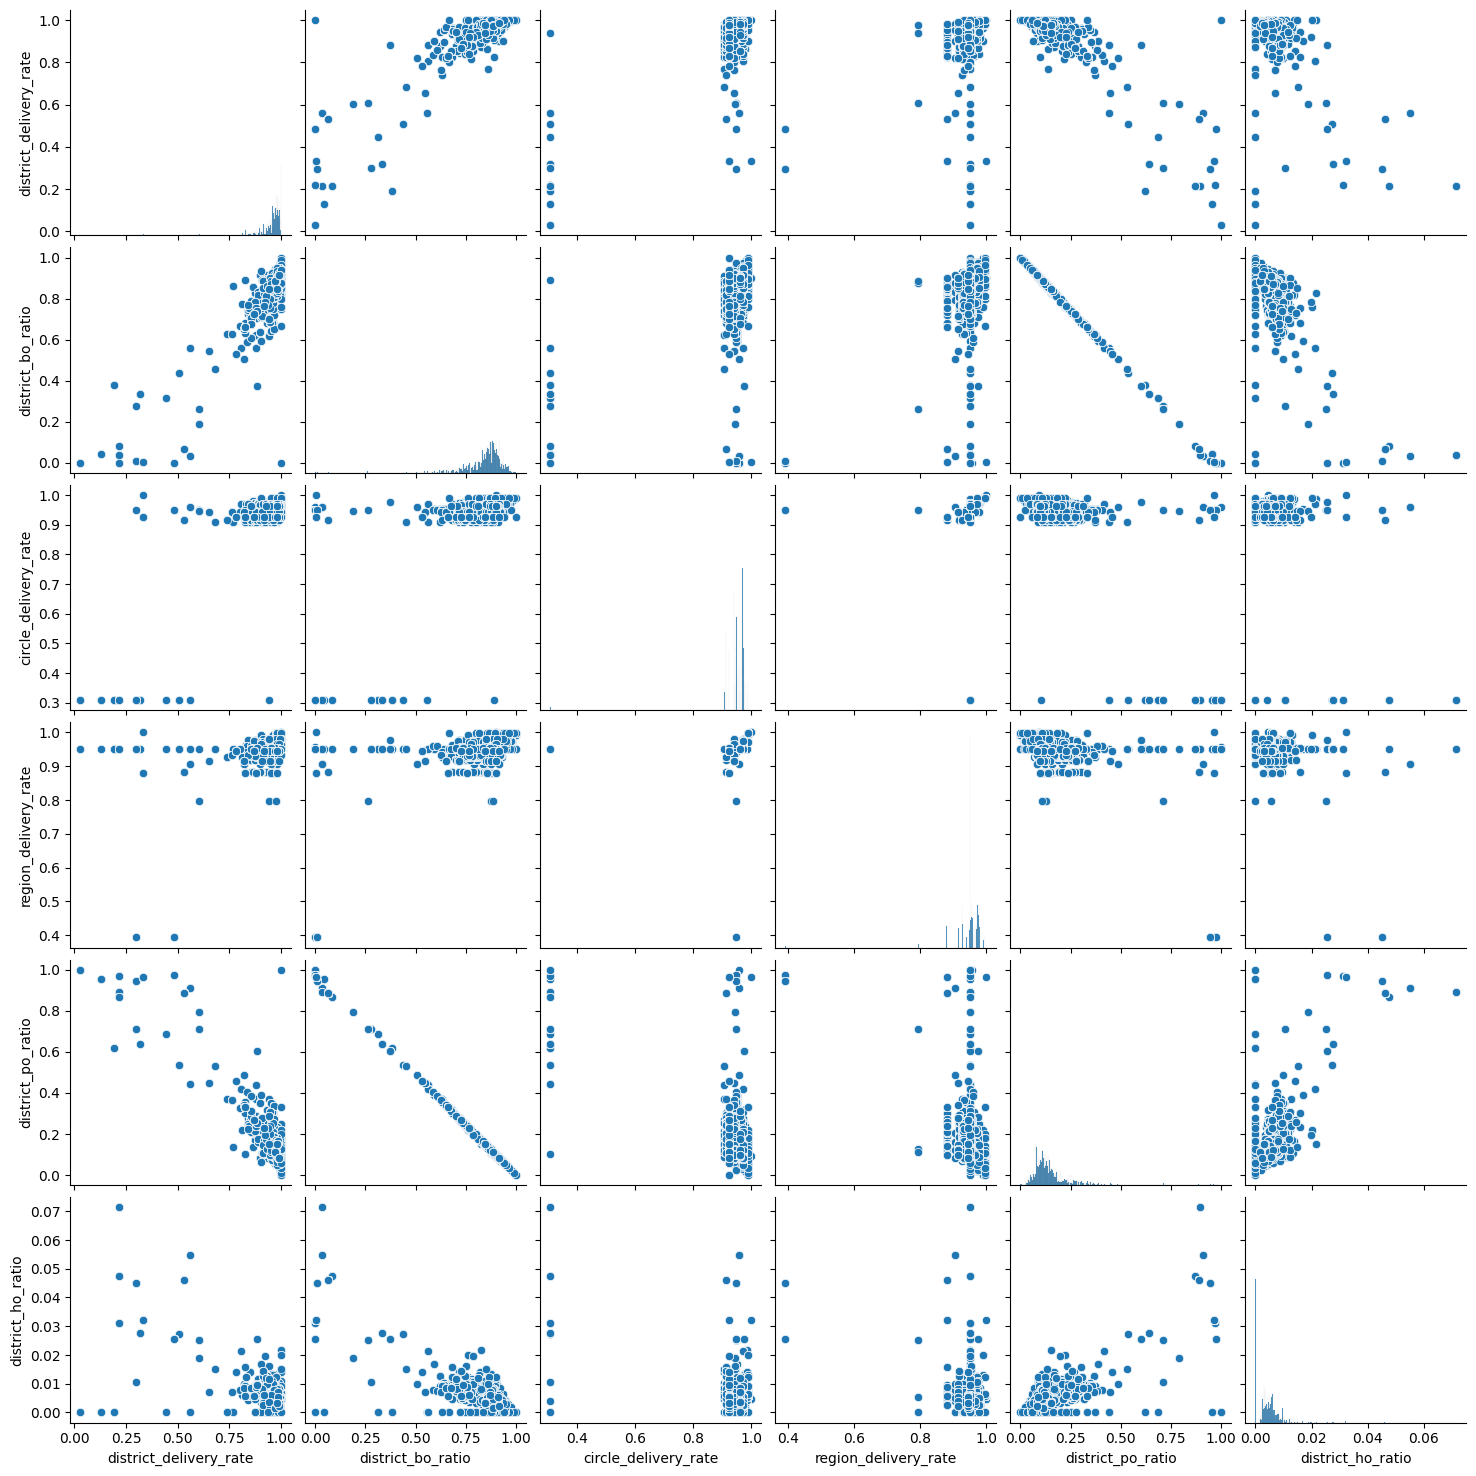

In [29]:
#STEP 4: MULTIVARIATE ANALYSIS
#4.1 Pairplot
# Selected important features only
important_cols = [
    'district_delivery_rate',
    'district_bo_ratio',
    'circle_delivery_rate',
    'region_delivery_rate',
    'district_po_ratio',
    'district_ho_ratio'
]

sns.pairplot(df[important_cols])
plt.show()

**🔎 Multivariate Analysis Summary**

* The pairplot reveals strong relationships between infrastructure composition and delivery performance.
* District BO ratio shows a strong positive association with district delivery rate, while district PO ratio exhibits a strong negative relationship. Circle and regional delivery rates also demonstrate moderate positive correlations, suggesting hierarchical influence on district performance.
* A strong inverse relationship between BO ratio and PO ratio indicates multicollinearity, which should be addressed during modeling.

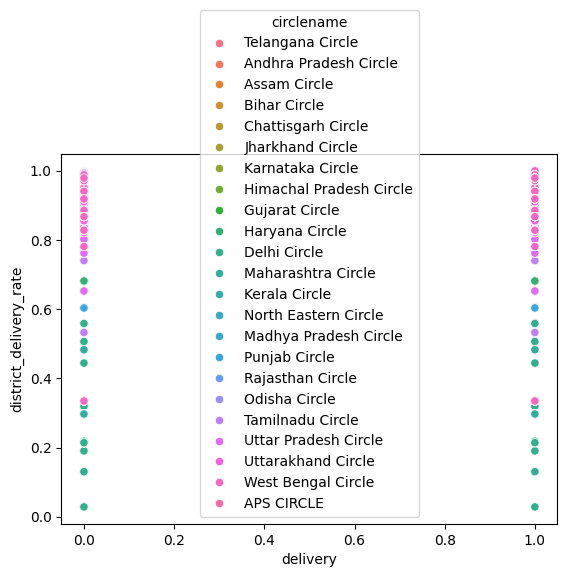

In [30]:
#4.2 Feature Interaction with Hue
sns.scatterplot(
    x=df[num_cols[0]],
    y=df['district_delivery_rate'],
    hue=df[cat_cols[0]] if len(cat_cols)>0 else None
)
plt.show()

**🔎 Feature Interaction with Hue – Summary**

* The scatterplot with circlename as hue reveals that delivery performance varies across administrative circles. Districts with successful delivery (delivery = 1) predominantly exhibit high district delivery rates, while unsuccessful cases show greater variability and lower performance.
* Certain circles demonstrate tighter clustering near high delivery rates, indicating consistent performance, whereas others show wider dispersion and more low-value outliers. This suggests that regional administrative factors influence district-level delivery efficiency.

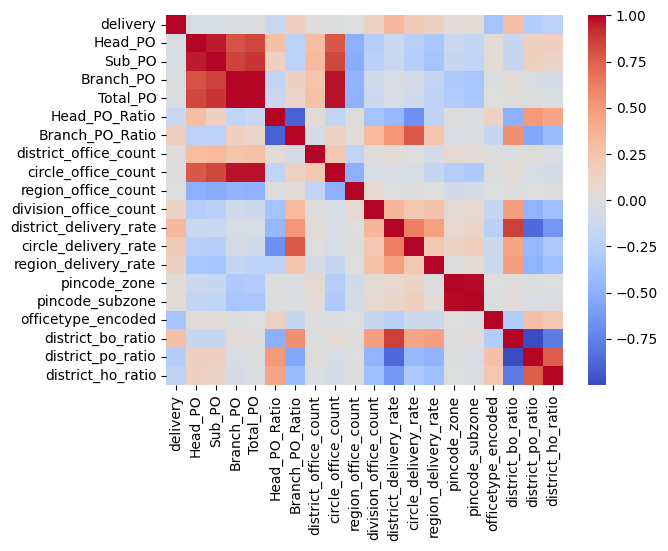

In [32]:
#STEP 5: Multicollinearity Check
plt.figure()
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.show()

**🔎 Multicollinearity Analysis Summary**

* The correlation heatmap reveals strong multicollinearity among infrastructure count variables such as Head_PO, Sub_PO, Branch_PO, and Total_PO, indicating redundancy. Additionally, district office ratio variables (district_bo_ratio, district_po_ratio, district_ho_ratio) exhibit strong inverse relationships due to structural dependency.

* Pincode_zone and pincode_subzone are almost perfectly correlated, suggesting that only one should be retained.

* To ensure stable and interpretable modeling, redundant variables will be removed prior to regression analysis.